In [21]:
reg = np.random.default_rng(7)
class0 = reg.normal(loc=[1.5,1.5],scale=0.45,size=(40,2))
class1 = reg.normal(loc=[4.0,4.0],scale=0.45,size=(40,2))

X = np.vstack([class0,class1])
y = np.array([0]*40+[1]*40)

w = np.zeros(2) 
lr = 0.1 
b = 0.0

for e in range(10) :
    error = 0 
    for i in range(len(X)) : 
        net= np.dot(X[i],w) + b 
        y_hat = 1 if net>=0 else 0 
        update = lr * (y[i]-y_hat) 
        w += update * X[i] 
        b += update 

        if update != 0 : 
            error += 1 
    print("epoch :",e+1,"error : ",error) 
    
    if(error == 0 ) : break 

epoch : 1 error :  2
epoch : 2 error :  3
epoch : 3 error :  2
epoch : 4 error :  0


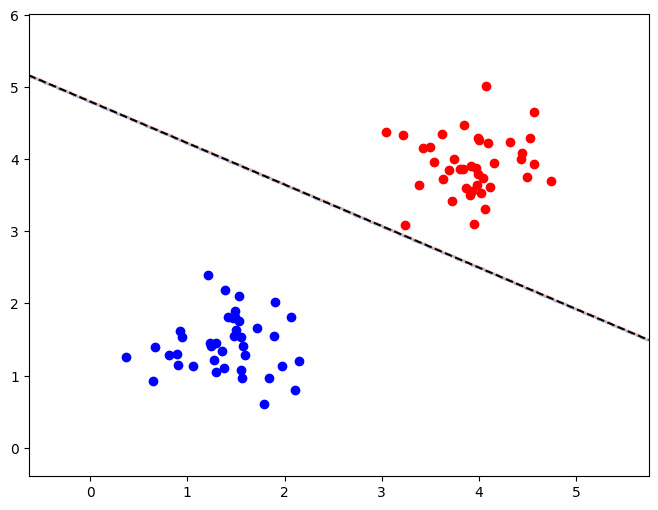

In [56]:
xmin,xmax = X[:,0].min() -1 ,X[:,0].max() + 1
ymin,ymax = X[:,1].min() -1 ,X[:,1].max() + 1

xx,yy = np.meshgrid(np.linspace(xmin,xmax,300),np.linspace(ymin,ymax,300)) 

grid = np.c_[xx.ravel(),yy.ravel()]

Z = np.array([1 if np.dot(w,p) + b >= 0 else 0 for p in grid]).reshape(xx.shape) 

plt.figure(figsize=(8,6))
plt.contour(xx,yy,Z,alpha=0.25,cmap='coolwarm')
plt.scatter(class0[:,0],class0[:,1],c='blue',label="class 0")
plt.scatter(class1[:,0],class1[:,1],c='red',label="class 1")
line_x = np.array([x_min, x_max])
line_y = -(w[0] * line_x + b) / w[1]
plt.plot(line_x, line_y, "k--", label="Decision boundary")